<a href="https://colab.research.google.com/github/syedafrose774/1BM23AI194_dst_aat_3c/blob/main/Copy_of_DEL_LAB_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Layer
import matplotlib.pyplot as plt

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Layer
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset and take a smaller subset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
subset_size = 1000
x_train = x_train[:subset_size] / 255.0
y_train = y_train[:subset_size]
x_test = x_test[:200] / 255.0
y_test = y_test[:200]

# ADVERSARIAL TRAINING
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model
 def generate_adversarial_examples(model, x, y, epsilon):
    # Generate adversarial examples using Fast Gradient Sign Method (FGSM)
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predictions = model(x_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_tensor, predictions)

    gradients = tape.gradient(loss, x_tensor)

    # Create adversarial examples
    signed_grad = tf.sign(gradients)
    x_adv = x_tensor + epsilon * signed_grad
    x_adv = tf.clip_by_value(x_adv, 0, 1)
    return x_adv.numpy()
model_adv = create_model()
model_adv.fit(x_train, y_train, epochs=5)
epsilon = 0.1
x_adv = generate_adversarial_examples(model_adv, x_test, y_test, epsilon)
x_combined = np.concatenate([x_test, x_adv])
y_combined = np.concatenate([y_test, y_test])
model_adv.fit(x_combined, y_combined, epochs=5, validation_data=(x_test, y_test))

class TangentProp(Layer):
  def call(self, x):
    pertubation = tf.random.normal(tf.shape(x), stddev = 0.1)
    return x + pertubation

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 27)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Layer
import matplotlib.pyplot as plt

# Load the Fashion MNIST dataset and take a smaller subset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
subset_size = 1000
x_train = x_train[:subset_size] / 255.0
y_train = y_train[:subset_size]
x_test = x_test[:200] / 255.0
y_test = y_test[:200]

# ADVERSARIAL TRAINING
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def generate_adversarial_examples(model, x, y, epsilon):
    # Generate adversarial examples using Fast Gradient Sign Method (FGSM)
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predictions = model(x_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_tensor, predictions)
    gradients = tape.gradient(loss, x_tensor)

    # Create adversarial examples
    signed_grad = tf.sign(gradients)
    x_adv = x_tensor + epsilon * signed_grad
    x_adv = tf.clip_by_value(x_adv, 0, 1)

    return x_adv.numpy()

# Train model with Adversarial Training
model_adv = create_model()
x_adv = generate_adversarial_examples(model_adv, x_train, y_train, epsilon=0.1)

x_combined = np.concatenate([x_train, x_adv])
y_combined = np.concatenate([y_train, y_train])

history_adv = model_adv.fit(x_combined, y_combined, epochs=5,
                            validation_data=(x_test, y_test), verbose=1)

loss_adv, accuracy_adv = model_adv.evaluate(x_test, y_test, verbose=0)
print(f'\nAdversarially Trained Model Accuracy: {accuracy_adv * 100:.2f}%')


class TangentProp(Layer):
    def call(self, x):
        perturbation = tf.random.normal(shape=tf.shape(x), stddev=0.1)
        return x + perturbation

# Apply Tangent Prop to the model
model_tangent_prop = create_model()
model_tangent_prop.add(TangentProp())
history_tangent_prop = model_tangent_prop.fit(x_train, y_train, epochs=5,
                                              validation_data=(x_test, y_test), verbose=0)

loss, accuracy_tangent_prop = model_tangent_prop.evaluate(x_test, y_test, verbose=0)
print(f'Adversarially Trained Model with Tangent Prop Accuracy: {accuracy_tangent_prop * 100:.2f}%')

# TANGENT DISTANCE
def tangent_distance(x1, x2):
    return np.linalg.norm(x1 - x2)

# TANGENT CLASSIFIER
def classify_with_tangent_distance(x_train, y_train, x_test):
    x_train_flat = x_train.reshape(x_train.shape[0], -1)
    x_test_flat = x_test.reshape(x_test.shape[0], -1)

def classify_with_tangent_distance(x_train, y_train, x_test):
    x_train_flat = x_train.reshape(x_train.shape[0], -1)
    x_test_flat = x_test.reshape(x_test.shape[0], -1)
    y_pred = []

    print(f"Classifying {len(x_test_flat)} test samples...")
    for i, test_sample in enumerate(x_test_flat):
        if (i + 1) % 20 == 0:
            print(f"Progress: {(i + 1) / len(x_test_flat):.1%}")
        distances = [tangent_distance(test_sample, train_sample) for train_sample in x_train_flat]
        nearest_index = np.argmin(distances)
        y_pred.append(y_train[nearest_index])

    return np.array(y_pred)

    y_pred_tangent = classify_with_tangent_distance(x_train, y_train, x_test)
    accuracy_tangent = np.mean(y_pred_tangent == y_test)
    print(f'\nTangent Distance Classifier Accuracy: {accuracy_tangent * 100:.2f}%')

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history_adv.history['loss'], label='Adversarial Training Loss', marker = 'o')
    plt.plot(history_tangent_prop.history['loss'], label='Tangent Prop Training Loss', marker = 'o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss Comparison')
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.subplot(1, 2, 2)
    plt.plot(history_adv.history['accuracy'], label='Adversarial Training', marker = 'o')
    plt.plot(history_tangent_prop.history['accuracy'], label='Tangent Prop Training', marker = 'o')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training Accuracy Comparison')
    plt.legend()
    plt.grid(True, alpha = 0.3)
    plt.tight_layout()
    plt.show()

    print(f'\nAdversarial Training Accuracy: {accuracy_adv * 100:.2f}%')
    print(f'Tangent Prop Training Accuracy: {accuracy_tangent_prop * 100:.2f}%')
    print(f'Tangent Distance Classifier Accuracy: {accuracy_tangent * 100:.2f}%')

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2834 - loss: 2.1812 - val_accuracy: 0.6700 - val_loss: 0.9693
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6662 - loss: 0.9743 - val_accuracy: 0.7050 - val_loss: 0.7760
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7780 - loss: 0.7106 - val_accuracy: 0.7150 - val_loss: 0.6955
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8404 - loss: 0.5451 - val_accuracy: 0.7700 - val_loss: 0.6461
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8702 - loss: 0.4436 - val_accuracy: 0.7600 - val_loss: 0.5995

Adversarially Trained Model Accuracy: 76.00%
Adversarially Trained Model with Tangent Prop Accuracy: 72.00%


Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.4292 - loss: 1.6171 - val_accuracy: 0.7300 - val_loss: 0.7697
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7050 - loss: 0.8658 - val_accuracy: 0.7250 - val_loss: 0.6759
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8238 - loss: 0.6049 - val_accuracy: 0.7900 - val_loss: 0.6010
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8676 - loss: 0.4470 - val_accuracy: 0.7550 - val_loss: 0.6142
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8899 - loss: 0.3798 - val_accuracy: 0.7150 - val_loss: 0.6914
Epoch 1/5


/tmp/ipython-input-2874369614.py:68: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  TangentProp(input_shape=(28, 28)),


32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.3486 - loss: 1.8520 - val_accuracy: 0.6450 - val_loss: 1.0613
Epoch 2/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7164 - loss: 0.8735 - val_accuracy: 0.7300 - val_loss: 0.7610
Epoch 3/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7493 - loss: 0.7539 - val_accuracy: 0.7300 - val_loss: 0.8054
Epoch 4/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7823 - loss: 0.6183 - val_accuracy: 0.7600 - val_loss: 0.6566
Epoch 5/5
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8062 - loss: 0.5561 - val_accuracy: 0.7800 - val_loss: 0.5929
Classifying 200 test samples...
Progress: 10.0%
Progress: 20.0%
Progress: 30.0%
Progress: 40.0%
Progress: 50.0%
Progress: 60.0%
Progress: 70.0%
Progress: 80.0%
Progress: 90.0%
Progress: 100.0%


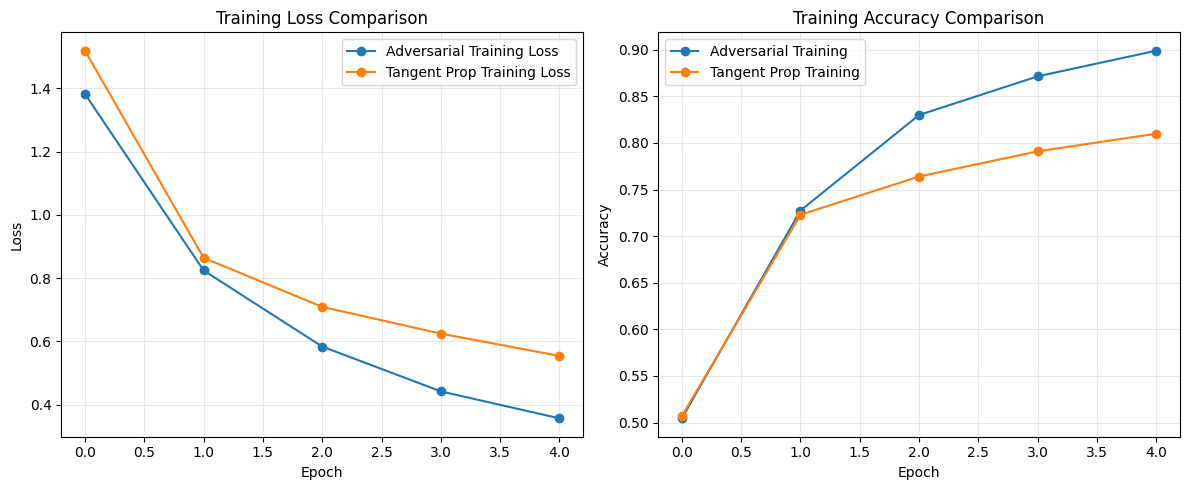


Adversarial Training Accuracy: 71.50%
Tangent Prop Training Accuracy: 77.00%
Tangent Distance Classifier Accuracy: 77.50%


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Layer
import matplotlib.pyplot as plt

# Load data
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
subset_size = 1000
x_train, y_train = x_train[:subset_size] / 255.0, y_train[:subset_size]
x_test, y_test = x_test[:200] / 255.0, y_test[:200]

# ----------------------------
# 1️⃣ Base Model Definition
# ----------------------------
def create_model():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ----------------------------
# 2️⃣ Adversarial Example Generation (FGSM)
# ----------------------------
def generate_adversarial_examples(model, x, y, epsilon=0.1):
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32)
    y_tensor = tf.convert_to_tensor(y, dtype=tf.int64)

    with tf.GradientTape() as tape:
        tape.watch(x_tensor)
        predictions = model(x_tensor)
        loss = tf.keras.losses.sparse_categorical_crossentropy(y_tensor, predictions)
    gradients = tape.gradient(loss, x_tensor)
    x_adv = x_tensor + epsilon * tf.sign(gradients)
    return tf.clip_by_value(x_adv, 0, 1).numpy()

# ----------------------------
# 3️⃣ Adversarial Training
# ----------------------------
model_adv = create_model()
# Pretrain a bit to get meaningful gradients
model_adv.fit(x_train, y_train, epochs=1, verbose=0)

x_adv = generate_adversarial_examples(model_adv, x_train, y_train, epsilon=0.1)
x_combined = np.concatenate([x_train, x_adv])
y_combined = np.concatenate([y_train, y_train])

history_adv = model_adv.fit(x_combined, y_combined, epochs=5,
                            validation_data=(x_test, y_test), verbose=1)
loss_adv, accuracy_adv = model_adv.evaluate(x_test, y_test, verbose=0)

# ----------------------------
# 4️⃣ Tangent Prop Layer
# ----------------------------
class TangentProp(Layer):
    def call(self, x):
        perturbation = tf.random.normal(shape=tf.shape(x), stddev=0.1)
        return x + perturbation

# Tangent Prop model
model_tangent_prop = Sequential([
    TangentProp(input_shape=(28, 28)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])
model_tangent_prop.compile(optimizer='adam',
                           loss='sparse_categorical_crossentropy',
                           metrics=['accuracy'])
history_tangent_prop = model_tangent_prop.fit(
    x_train, y_train, epochs=5,
    validation_data=(x_test, y_test), verbose=1
)
loss_tangent_prop, accuracy_tangent_prop = model_tangent_prop.evaluate(x_test, y_test, verbose=0)

# ----------------------------
# 5️⃣ Tangent Distance (Euclidean)
# ----------------------------
def tangent_distance(x1, x2):
    return np.linalg.norm(x1 - x2)

def classify_with_tangent_distance(x_train, y_train, x_test):
    x_train_flat = x_train.reshape(x_train.shape[0], -1)
    x_test_flat = x_test.reshape(x_test.shape[0], -1)
    y_pred = []

    print(f"Classifying {len(x_test_flat)} test samples...")
    for i, test_sample in enumerate(x_test_flat):
        if (i + 1) % 20 == 0:
            print(f"Progress: {(i + 1) / len(x_test_flat):.1%}")
        distances = np.linalg.norm(x_train_flat - test_sample, axis=1)
        nearest_index = np.argmin(distances)
        y_pred.append(y_train[nearest_index])
    return np.array(y_pred)

y_pred_tangent = classify_with_tangent_distance(x_train, y_train, x_test)
accuracy_tangent = np.mean(y_pred_tangent == y_test)

# ----------------------------
# 6️⃣ Plot and Results
# ----------------------------
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_adv.history['loss'], label='Adversarial Training Loss', marker='o')
plt.plot(history_tangent_prop.history['loss'], label='Tangent Prop Training Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_adv.history['accuracy'], label='Adversarial Training', marker='o')
plt.plot(history_tangent_prop.history['accuracy'], label='Tangent Prop Training', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nAdversarial Training Accuracy: {accuracy_adv * 100:.2f}%')
print(f'Tangent Prop Training Accuracy: {accuracy_tangent_prop * 100:.2f}%')
print(f'Tangent Distance Classifier Accuracy: {accuracy_tangent * 100:.2f}%')
